**Taller: Modelos de Regresión - Predicción de Precios de Autos Usados** Anggie Dayanna García Orrego

En este taller se aplicarán técnicas de regresión para predecir el precio de vehículos usados a partir de sus características, siguiendo las etapas de preparación, modelado y evaluación de datos.

# Paso 0: Importación de librerías esenciales

In [68]:
# Librerías para manipular datos
import pandas as pd
import numpy as np

# Librerías para realizar gráficas
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para dividir los datos
from sklearn.model_selection import train_test_split

# Librería para escalar las variables
from sklearn.preprocessing import StandardScaler

# Modelos de regresión
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Métricas para evaluar los modelos
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 1. Carga de Datos y Análisis Exploratorio Inicial

In [69]:
# Paso 1: Cargar el dataset
datos = pd.read_csv("cardekho.csv")

# Se muestran las primeras filas para conocer la estructura del conjunto de datos y verificar que el archivo se haya cargado correctamente.
datos.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [70]:
# Se revisa el tipo de dato de cada columna y la cantidad de valores nulos
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   str    
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   str    
 5   seller_type         8128 non-null   str    
 6   transmission        8128 non-null   str    
 7   owner               8128 non-null   str    
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   str    
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), str(6)
memory usage: 762.1 KB


In [71]:
# verificamos datos faltantes
datos.isnull().sum()

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             215
seats                 221
dtype: int64

In [72]:
# Este resumen estadístico permite conocer valores mínimos, máximos, promedio y desviación estándar de las variables numéricas
datos.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000,7907.000000,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.418783,1458.625016,5.416719
std,4.044249,8.062534e+05,5.655055e+04,4.037145,503.916303,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.780000,1197.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,14.000000


<Figure size 800x500 with 0 Axes>

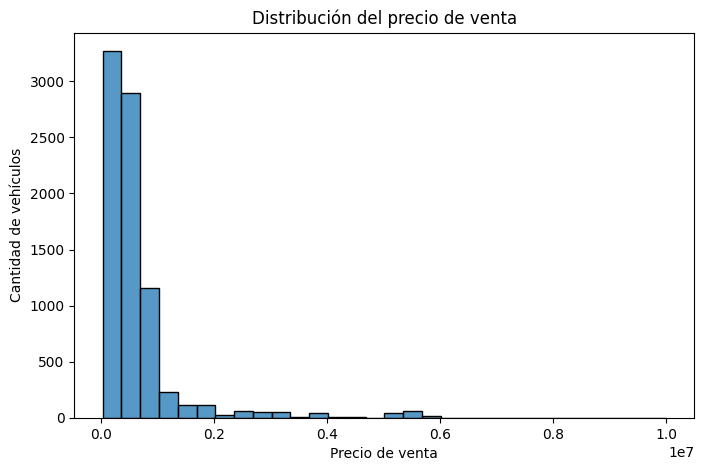

In [73]:
# Gráfica exploratoria
# Esta gráfica permite analizar la distribución de la variable objetivo (selling_price), identificando la concentración de los precios, la posible presencia de valores 
# atípicos y el grado de asimetría de los atípicos y el grado de asimetría de los
plt.figure(figsize=(8,5))
plt.figure(figsize=(8,5))
sns.histplot(datos["selling_price"], bins=30)
plt.title("Distribución del precio de venta")
plt.xlabel("Precio de venta")
plt.ylabel("Cantidad de vehículos")
plt.show()

In [74]:
# La distribución del precio de venta presenta una asimetría positiva, concentrando la mayor cantidad de vehículos en rangos de precios bajos y mostrando una 
# cola hacia valores altos. Esto indica la presencia de algunos vehículos con precios significativamente superiores al resto, lo que indica la existencia de valores atípicos

# 2. Preprocesamiento de Datos e Ingeniería de Características

In [75]:
# Paso 2: Limpieza y transformación de datos

# La columna name contiene demasiados valores diferentes, por lo que no aporta al entrenamiento del modelo

datos = datos.drop("name", axis=1)

In [76]:
# Convertir la variable owner a valores numéricos
datos["owner"] = datos["owner"].replace({
    "First Owner":1,
    "Second Owner":2,
    "Third Owner":3,
    "Fourth & Above Owner":4,
    "Test Drive Car":5
})

In [77]:
# Convertir columna max_power a numérica

datos["max_power"] = datos["max_power"].astype(str)

datos["max_power"] = datos["max_power"].str.extract(r'([\d.]+)')

datos["max_power"] = pd.to_numeric(datos["max_power"], errors="coerce")

In [78]:
# Convertir variables categóricas en variables numéricas
datos = pd.get_dummies(
    datos,
    columns=["fuel","seller_type","transmission"],
    drop_first=True
)

In [79]:
# Verificar valores nulos nuevamente
datos.isnull().sum()

year                              0
selling_price                     0
km_driven                         0
owner                             0
mileage(km/ltr/kg)              221
engine                          221
max_power                       216
seats                           221
fuel_Diesel                       0
fuel_LPG                          0
fuel_Petrol                       0
seller_type_Individual            0
seller_type_Trustmark Dealer      0
transmission_Manual               0
dtype: int64

In [80]:
# Eliminar registros con datos faltantes
datos = datos.dropna()

In [81]:
# Escalado de los datos
# Definir las variables predictoras (X) y la variable objetivo (y)

# Variable objetivo
y = datos["selling_price"]

# Variables predictoras
X = datos.drop("selling_price", axis=1)

# Divisón del Dataset

In [82]:
# Se divide el dataset en datos de entrenamiento (80%) y datos de prueba (20%) para evaluar el desempeño
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42)

# Mostrar el tamaño de cada conjunto
print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)
print("Tamaño de y_train:", y_train.shape)
print("Tamaño de y_test:", y_test.shape)


Tamaño de X_train: (6324, 13)
Tamaño de X_test: (1582, 13)
Tamaño de y_train: (6324,)
Tamaño de y_test: (1582,)


In [83]:
# Escalar las variables
# Se aplica StandardScaler para que todas las variables tengan una escala similar. El escalado se realiza después de dividir los datos para evitar fuga de información 
# entre el entrenamiento y la prueba

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Entrenamiento de Modelos

In [84]:
# Modelo 1: Regresión Lineal: busca encontrar una relación lineal entre las variables predictoras y el precio de venta del vehículo

# Crear el modelo
modelo_lineal = LinearRegression()

# Entrenar el modelo
modelo_lineal.fit(X_train, y_train)

# Realizar predicciones
pred_lineal = modelo_lineal.predict(X_test)

In [85]:
# Modelo 2: Árbol de Decisión: divide los datos mediante reglas para realizar las predicciones del precio de venta

# Crear el modelo
modelo_arbol = DecisionTreeRegressor(random_state=42)

# Entrenar el modelo
modelo_arbol.fit(X_train, y_train)

# Realizar predicciones
pred_arbol = modelo_arbol.predict(X_test)

In [86]:
# Modelo 3: Random Forest: ombina múltiples árboles de decisión para obtener predicciones más precisas y reducir el sobreajuste

# Crear el modelo
modelo_random = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Entrenar el modelo
modelo_random.fit(X_train, y_train)

# Realizar predicciones
pred_random = modelo_random.predict(X_test)

In [87]:
# Comparar predicciones: se comparan los valores reales con las predicciones realizadas por cada uno de los modelos.

comparacion = pd.DataFrame({
    "Valor Real": y_test.values,
    "Regresión Lineal": pred_lineal,
    "Árbol de Decisión": pred_arbol,
    "Random Forest": pred_random
})

comparacion.head(10)

,Valor Real,Regresión Lineal,Árbol de Decisión,Random Forest
0,501000,6.452411e+05,650000.0,564869.950000
1,440000,4.117562e+05,510000.0,518653.323333
2,140000,9.261832e+04,168000.0,163869.960000
3,476999,4.641154e+05,415000.0,338499.990000
4,620000,1.076992e+06,620000.0,587178.551429
5,380000,6.801548e+05,350000.0,322090.000000
6,360000,6.074670e+05,500000.0,519959.800000
7,185000,4.971080e+05,135000.0,137910.000000
8,157000,-2.039205e+05,121000.0,119275.000000
9,600000,4.663851e+05,600000.0,403369.960000


In [88]:
# Calcular el Error Cuadrático Medio (RMSE) para cada modelo
# representa el error promedio de las predicciones. Un valor más pequeño indica que el modelo realiza estimaciones más cercanas al precio real de los vehículos

rmse_lineal = np.sqrt(mean_squared_error(y_test, pred_lineal))
rmse_arbol = np.sqrt(mean_squared_error(y_test, pred_arbol))
rmse_random = np.sqrt(mean_squared_error(y_test, pred_random))

print("RMSE Regresión Lineal:", round(rmse_lineal,2))
print("RMSE Árbol de Decisión:", round(rmse_arbol,2))
print("RMSE Random Forest:", round(rmse_random,2))

RMSE Regresión Lineal: 460216.04
RMSE Árbol de Decisión: 155300.1
RMSE Random Forest: 106839.65


# 5. Evaluación y Comparación de Resultados

In [89]:
# Cálculo del coeficiente de determinación (R²): indica qué tan bien explica cada modelo la variación del precio de los vehículos, entre más cercano sea a 1, mejor será el modelo

# R² de la Regresión Lineal
r2_lineal = r2_score(y_test, pred_lineal)

# R² del Árbol de Decisión
r2_arbol = r2_score(y_test, pred_arbol)

# R² del Random Forest
r2_random = r2_score(y_test, pred_random)

# Mostrar los resultados
print("R² Regresión Lineal:", round(r2_lineal,4))
print("R² Árbol de Decisión:", round(r2_arbol,4))
print("R² Random Forest:", round(r2_random,4))

R² Regresión Lineal: 0.6954
R² Árbol de Decisión: 0.9653
R² Random Forest: 0.9836


In [90]:
# Comparar las métricas de los modelos

metricas = pd.DataFrame({
    "Modelo": [
        "Regresión Lineal",
        "Árbol de Decisión",
        "Random Forest"
    ],
    "R²": [
        r2_lineal,
        r2_arbol,
        r2_random
    ],
    "RMSE": [
        rmse_lineal,
        rmse_arbol,
        rmse_random
    ]
})

metricas

,Modelo,R²,RMSE
0,Regresión Lineal,0.695378,460216.044209
1,Árbol de Decisión,0.965312,155300.099740
2,Random Forest,0.983583,106839.648855


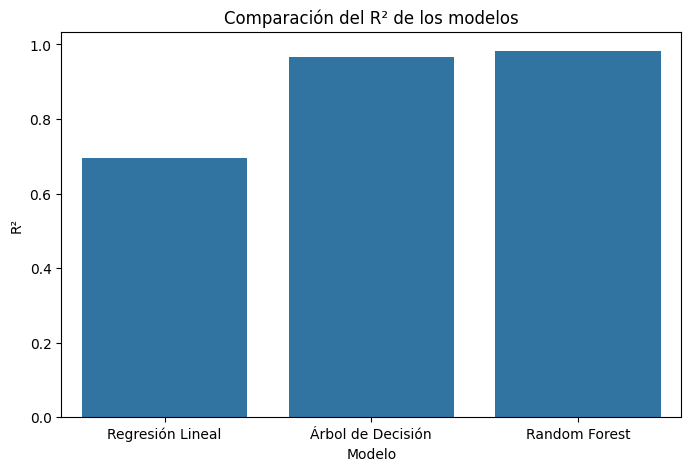

In [91]:
# Comparación del R² mediante gráfico de barras

plt.figure(figsize=(8,5))
sns.barplot(
    data=metricas,
    x="Modelo",
    y="R²")

plt.title("Comparación del R² de los modelos")
plt.xlabel("Modelo")
plt.ylabel("R²")
plt.show()

In [92]:
# El modelo Random Forest que tiene la barra más alta presenta un mejor desempeño, ya que logra explicar una mayor proporción de la variabilidad del precio de venta

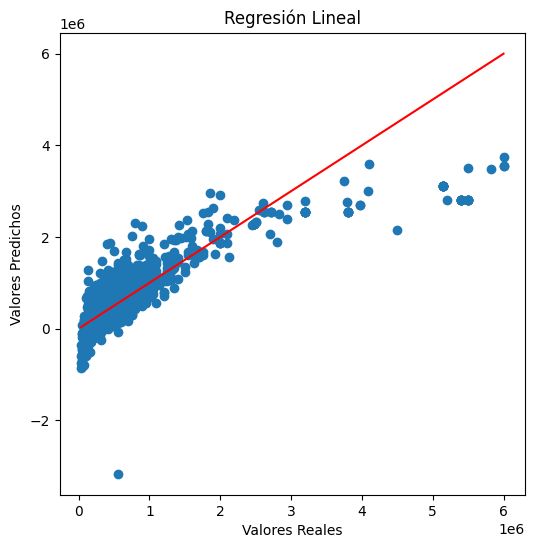

In [93]:
# Gráfica de Valores Reales vs Valores Predichos

# Modelo 1: Regresión Lineal

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_lineal)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red")

plt.title("Regresión Lineal")
plt.xlabel("Valores Reales")
plt.ylabel("Valores Predichos")
plt.show()

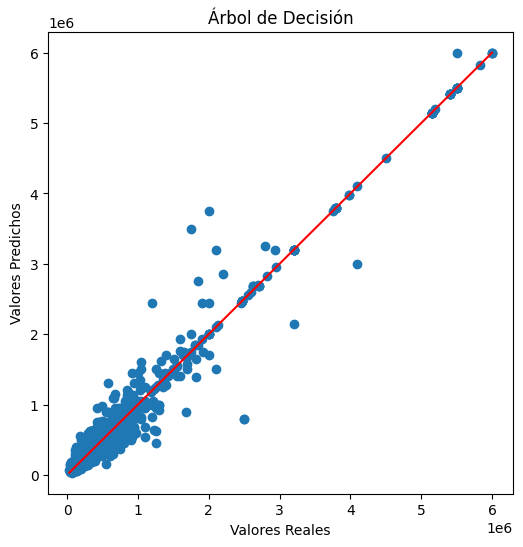

In [94]:
# Modelo 2: Árbol de Decisión

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_arbol)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red")

plt.title("Árbol de Decisión")
plt.xlabel("Valores Reales")
plt.ylabel("Valores Predichos")
plt.show()

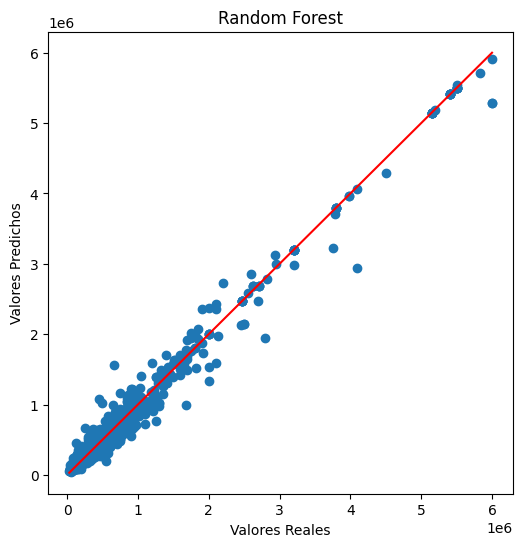

In [95]:
# Modelo 3: Random Forest

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_random)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red")

plt.title("Random Forest")
plt.xlabel("Valores Reales")
plt.ylabel("Valores Predichos")
plt.show()

In [96]:
# Identificar el mejor modelo según el R²
# selecciona el modelo con el mayor valor de R², ya que es el que mejor explica la variación del precio de los vehículos y en conjunto con el RMSE, 
# permite identificar el modelo con mejor capacidad predictiva

mejor_modelo = metricas.loc[metricas["R²"].idxmax()]

print("El mejor modelo fue:", mejor_modelo["Modelo"])
print("R²:", round(mejor_modelo["R²"],4))
print("RMSE:", round(mejor_modelo["RMSE"],2))

El mejor modelo fue: Random Forest
R²: 0.9836
RMSE: 106839.65


In [97]:
# Resumen 

metricas = metricas.sort_values(by="R²", ascending=False)

print("Resumen final de los modelos evaluados:")
display(metricas)

Resumen final de los modelos evaluados:


,Modelo,R²,RMSE
2,Random Forest,0.983583,106839.648855
1,Árbol de Decisión,0.965312,155300.099740
0,Regresión Lineal,0.695378,460216.044209


**ANÁLISIS DE RESULTADOS**

Después de entrenar y evaluar los tres modelos de regresión, se determinó que **Random Forest** fue el modelo con mejor desempeño. Esta decisión se fundamenta en que obtuvo el mayor coeficiente de determinación (**R² = 0.9836**), indicando que explica aproximadamente el **98,36 %** de la variación del precio de los vehículos. Además, presentó el menor **RMSE (106839.65)**, lo que significa que sus predicciones tuvieron el menor error promedio respecto a los valores reales.

La gráfica de comparación del R² muestra que Random Forest supera a los demás modelos, y en la gráfica de valores reales versus valores predichos sus predicciones se encuentran más cercanas a la línea de referencia, evidenciando un mejor ajuste. Por estas razones, se seleccionó como el modelo más adecuado para este problema de predicción de precios de vehículos usados.

**CONCLUSIONES**

1. El proceso de preprocesamiento permitió preparar correctamente el conjunto de datos para el entrenamiento de los modelos. Se eliminaron variables que no aportaban información relevante, se transformaron las variables categóricas mediante One-Hot Encoding y se verificó el tipo de dato de las variables numéricas, obteniendo un conjunto de datos apto para aplicar modelos de regresión.

2. La comparación entre los tres algoritmos evidenció diferencias importantes en su capacidad de predicción. La Regresión Lineal presentó el mayor error de predicción, lo que indica que las relaciones entre las variables y el precio de venta no son completamente lineales. En cambio, los modelos basados en árboles lograron representar mejor el comportamiento del conjunto de datos.

3. El modelo Random Forest obtuvo el mejor desempeño entre los modelos evaluados, ya que presentó el menor valor de RMSE (106.839,65), lo que significa que sus predicciones estuvieron, en promedio, más cerca de los valores reales del precio de los vehículos. El Árbol de Decisión obtuvo un desempeño intermedio, mientras que la Regresión Lineal registró el mayor error. Estos resultados se evidenciaron en las métricas obtenidas durante la evaluación del modelo.

4. Las gráficas de Valores Reales vs. Valores Predichos confirmaron visualmente el comportamiento de los modelos. En el caso de Random Forest, la mayor parte de las predicciones se ubicó más cerca de la línea de referencia, indicando una mayor precisión. Por el contrario, la Regresión Lineal presentó una mayor dispersión de los puntos, reflejando un menor ajuste a los datos.

5. Este taller permitió comprender la importancia de evaluar varios modelos antes de seleccionar uno para un problema de regresión. Aunque todos los algoritmos fueron entrenados con el mismo conjunto de datos, sus resultados fueron diferentes, demostrando que la elección del modelo influye directamente en la calidad de las predicciones y que la comparación mediante métricas como R² y RMSE es fundamental para seleccionar la mejor alternativa.